Compare different CV with deepLDA CV

## Setup

In [2]:
import os
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import plumed
import math

In [3]:
import torch
from mlcolvar.utils.io import load_dataframe


In [4]:
# Configurations
BASE_DIR    = Path("/home/dani/wslcoding/MCFM/ML-CV")
INPUT_DIR   = BASE_DIR / "input"
MD_IN_DIR   = INPUT_DIR / "md_inputs"
DATA_DIR    = BASE_DIR / "data"
GMX_CMD     = "gmx_mpi"  # I compiled gromacs with mpi support
TEST_NUM_STEPS   = 10_000     # for testing  
#NUM_STEPS   = 500_000    # productions
NUM_STEPS   = 10_000_000    # 20ns
STRIDE      = 10
#STRIDE      = 100

num_steps   = NUM_STEPS
test_num_steps = TEST_NUM_STEPS

os.chdir(BASE_DIR)

In [5]:
# Check working directory
os.getcwd()

'/home/dani/wslcoding/MCFM/ML-CV'

In [6]:
# helper functions

# delete outputs of simulations from `folder``
def clean(folder='./'):
    subprocess.run("rm -f bck.*.COLVAR bck.*.HILLS \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# delete outputs of simulations from `folder``
def clean_true(folder='./'):
    subprocess.run("rm -f bck.* COLVAR HILLS KERNELS alanine.* \\#*\\# alanine_prev.cpt", cwd=folder, shell=True)

# execute bash command in the given folder
def execute(command, folder, background=False):
    cmd = subprocess.run(command, cwd=folder, shell=True, capture_output = True, text=True, close_fds=background)
    if cmd.returncode == 0:
        print(f'Completed: {command}')
    else:
        print(cmd.stderr)

### biased simulation using $\phi$

In [7]:
# CREATE FOLDER AND COPY INPUTS
folder_phi = DATA_DIR / "2_biased-phi/"
Path(folder_phi).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_phi)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_phi)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [8]:
# WRITE PLUMED INPUT FILE
with open(folder_phi / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
#theta: TORSION ATOMS=6,5,7,9
#xi: TORSION ATOMS=16,15,17,19
#ene: ENERGY

# Compute descriptors
#INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Activate well-tempered metadynamics in phi
metad: METAD ARG=phi ...
   # Deposit a Gaussian every 500 time steps, with initial height 
   # equal to 1.2 kJ/mol and bias factor equal to 8 
   PACE=500 HEIGHT=1.2 BIASFACTOR=8 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE=HILLS GRID_MIN=-pi GRID_MAX=pi
...

# Print 
PRINT FMT=%g STRIDE={STRIDE} FILE=COLVAR ARG=phi,psi
ENDPLUMED
""")

In [9]:
#clean(folder_phi) # note: this deletes all previous results in folder!

In [10]:
# RUN GROMACS

#execute(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {test_num_steps} > alanine.out", folder=folder_phi)

In [11]:
# print command to run in terminal (for longer run)

print(f"cd {folder_phi}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} -v")

cd /home/dani/wslcoding/MCFM/ML-CV/data/2_biased-phi
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 10000000 -v


Text(0, 0.5, 'phi [rad]')

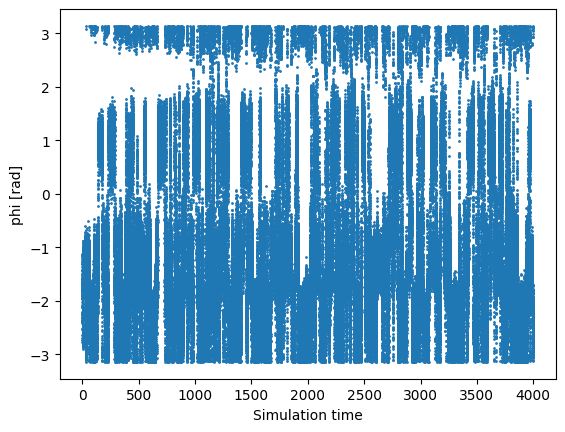

In [12]:
# visualize CV file
#data=plumed.read_as_pandas(str(folder_phi /"COLVAR"))
# use load_dataframe because plumed module give me errors
data=load_dataframe(f"{folder_phi}/COLVAR")
# plot phi during simulation (first 200k points)
plt.plot(data["time"][:200000],data["phi"][:200000],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("phi [rad]")

Text(0, 0.5, 'phi [rad]')

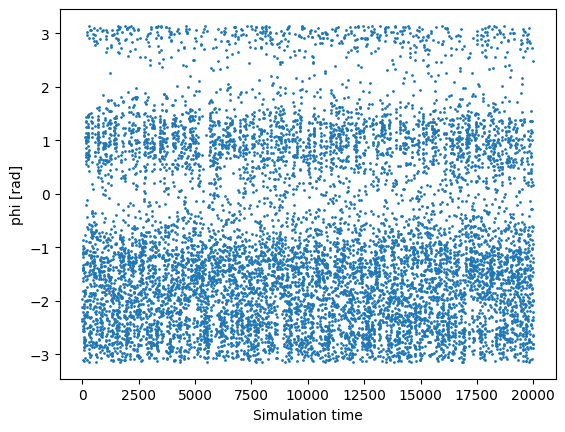

In [13]:
plt.plot(data["time"][::100],data["phi"][::100],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("phi [rad]")

Text(0, 0.5, 'height [kj/mol]')

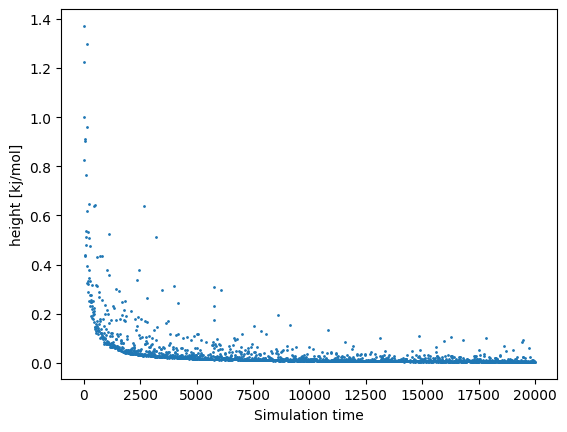

In [14]:
# visualize CV file
#data=plumed.read_as_pandas(str(folder_phi /"HILLS"))
data=load_dataframe(f"{folder_phi}/HILLS")
# plot phi during simulation (first 200k points)
plt.plot(data["time"][::10],data["height"][::10],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("height [kj/mol]")

In [15]:
data_phi=load_dataframe(f"{folder_phi}/COLVAR")
data_phi.head()

,time,phi,psi,walker
0,0.00,-2.36867,2.64432,0
1,0.02,-2.38391,2.56521,0
2,0.04,-2.22548,2.51866,0
3,0.06,-2.29910,2.43971,0
4,0.08,-2.21197,2.34191,0


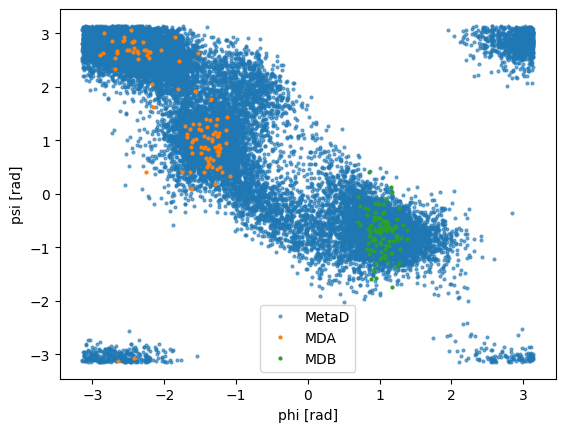

In [16]:
folderA = DATA_DIR / "0_unbiased-sA/"
folderB = DATA_DIR / "0_unbiased-sB/"

# dataA = plumed.read_as_pandas(str(folderA / "COLVAR"))
# dataB = plumed.read_as_pandas(str(folderB / "COLVAR"))
# data_phi=plumed.read_as_pandas(str(folder_phi /"COLVAR"))

dataA=load_dataframe(f"{folderA}/COLVAR")
dataB=load_dataframe(f"{folderB}/COLVAR")

# plot phi vs psi
plt.plot(data_phi["phi"][::50],data_phi["psi"][::50],'o', alpha=0.6, ms=2, label="MetaD")
plt.plot(dataA["phi"][::50],dataA["psi"][::50],'o', ms=2, label="MDA")
plt.plot(dataB["phi"][::50],dataB["psi"][::50],'o', ms=2, label="MDB")
# x-y axis labels
plt.xlabel("phi [rad]")
plt.ylabel("psi [rad]")
plt.legend()

In [17]:
# compute free energy as a function of simulation time

#plumed sum_hills --hills HILLS --stride 200 --mintozero
#execute("plumed sum_hills --hills HILLS --stride 200 --mintozero", folder=folder_phi)

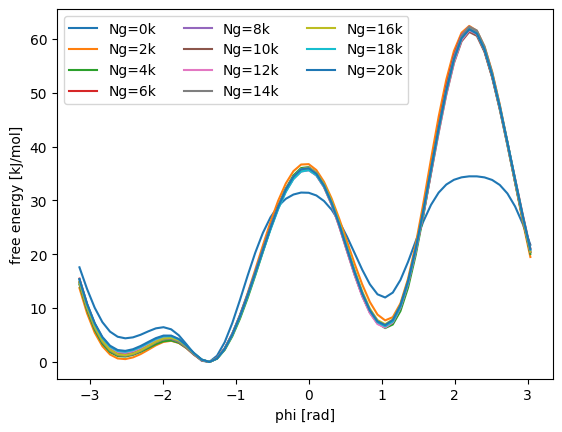

In [18]:
# plot free energy as a function of simulation time
#for i in range(0,51,10):
for i in range(0,101,10):    
 # import fes file into pandas dataset
#  data=plumed.read_as_pandas(str(folder_phi /"fes_")+str(i)+".dat")
 data = load_dataframe(f"{folder_phi}/fes_{i}.dat")

 # plot fes
 plt.plot(data["phi"],data["file.free"], label="Ng="+str(int(2*i/10))+"k") 
# labels
plt.xlabel("phi [rad]")
plt.ylabel("free energy [kJ/mol]")
plt.legend(ncol=3)

Text(0, 0.5, 'DeltaF [kJ/mol]')

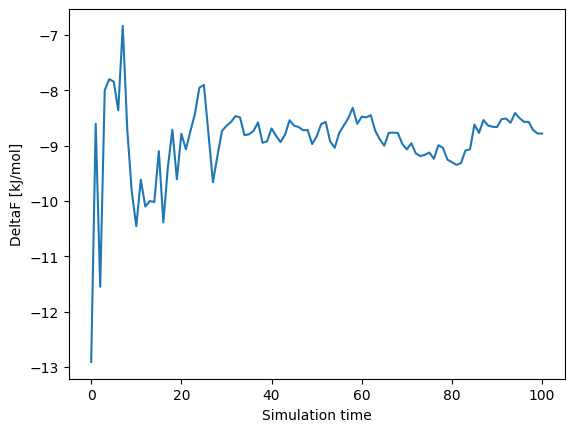

In [19]:
# calculate free-energy difference
DeltaF=[]; kbt=2.494339
# cycle on free-energy profiles
#for i in range(0,51):
for i in range(0,101):   
 # import fes file into pandas dataset
#  data=plumed.read_as_pandas(str(folder_phi /"fes_")+str(i)+".dat")
 data = load_dataframe(f"{folder_phi}/fes_{i}.dat")
 # find minimum value of fes
 minf = min(data["file.free"])
 # plot fes
 F0=0.0; F1=0.0
 for j in range(0, len(data["phi"])):
     phi = data["phi"][j]
     # calculate probability
     p = math.exp((-data["file.free"][j]+minf)/kbt)
     # integrate in the two basins
     if(-3<=phi<=-1):   F0 += p
     if(0.5<=phi<=1.5): F1 += p
 # calculate free energy difference and add to list
 DeltaF.append(-kbt*math.log(F0/F1))         
# plot
plt.plot(DeltaF) 
# labels
plt.xlabel("Simulation time")
plt.ylabel("DeltaF [kJ/mol]")

### reweighting

In [20]:
# CREATE FOLDER AND COPY INPUTS
folder_rw = DATA_DIR / "2_biased-phi-rw/"
Path(folder_rw).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_rw)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_rw)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [21]:
# WRITE PLUMED INPUT FILE
with open(folder_rw / "plumed_reweight.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
#theta: TORSION ATOMS=6,5,7,9
#xi: TORSION ATOMS=16,15,17,19
#ene: ENERGY

# Compute descriptors
#INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Activate well-tempered metadynamics in phi
metad: METAD ARG=phi ...
   # Deposit a Gaussian every 10000000 time steps (never!), with initial height equal to 0.0 kJ/mol 
   PACE=10000000 HEIGHT=0.0 BIASFACTOR=8# <- this is the new stuff! 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE={folder_phi}/HILLS GRID_MIN=-pi GRID_MAX=pi
   # Say that METAD should be restarting (= reading an existing HILLS file) 
   RESTART=YES # <- this is the new stuff! 
...

# Use the metadynamics bias as argument
as: REWEIGHT_BIAS ARG=metad.bias 
# Calculate histograms of phi and psi dihedrals every 50 steps
# using the weights obtained from the metadynamics bias potentials (umbrella-sampling-like reweighting)
# Look at the manual to understand the parameters of the HISTOGRAM action!
hhphi: HISTOGRAM ARG=phi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as 
hhpsi: HISTOGRAM ARG=psi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as 
# Convert histograms h(s) to free energies F(s) = -kBT * log(h(s))
ffphi: CONVERT_TO_FES GRID=hhphi 
ffpsi: CONVERT_TO_FES GRID=hhpsi 
# Print out the free energies F(s) to file once the entire trajectory is processed
DUMPGRID GRID=ffphi FILE=ffphi.dat 
DUMPGRID GRID=ffpsi FILE=ffpsi.dat 

# Print out the values of phi, psi and the metadynamics bias potential
# Make sure you print out the 3 variables in the specified order at every step
PRINT ARG=phi,psi,metad.bias FILE=COLVAR_REWEIGHT STRIDE=1 # <- also change this one!
ENDPLUMED
""")

In [22]:
# analyze with PLUMED driver
#execute(f"plumed driver --mf_xtc {folder_phi}/alanine.xtc --plumed plumed_reweight.dat --kt 2.494339", folder=folder_rw)

In [23]:
# now compare free energy from metadynamics bias and reweighting
#data_b=plumed.read_as_pandas(str(folder_phi / "fes_100.dat"))
#data_r=plumed.read_as_pandas(str(folder_rw / "ffphi.dat"))

In [24]:
# now compare free energy from metadynamics bias and reweighting
data_b=load_dataframe(f"{folder_phi}/fes_100.dat")
data_r=load_dataframe(f"{folder_rw}/ffphi.dat")               

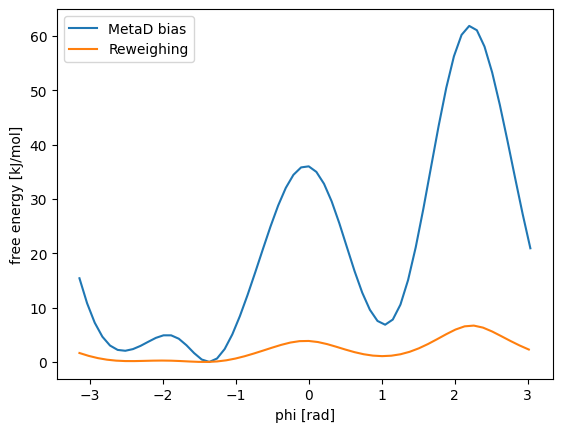

In [25]:


# plot free energies
plt.plot(data_b["phi"],data_b["file.free"],label="MetaD bias")
plt.plot(data_r["phi"],data_r["ffphi"]-min(data_r["ffphi"]),label="Reweighing")
# x-y axis labels
plt.xlabel("phi [rad]")
plt.ylabel("free energy [kJ/mol]")
plt.legend()

In [26]:
# colvar =plumed.read_as_pandas(str(folder_rw /"COLVAR_REWEIGHT"))
colvar =load_dataframe(f"{folder_rw}/COLVAR_REWEIGHT")

In [27]:
colvar.head()

,time,phi,psi,metad.bias,walker
0,0.0,-2.368269,2.643942,99.737540,0
1,1.0,-1.818813,2.266430,97.978734,0
2,2.0,-2.345259,2.601996,99.620770,0
3,3.0,-1.273902,0.118411,101.590225,0
4,4.0,-1.963553,2.974954,97.650720,0


(0.0, 50.0)

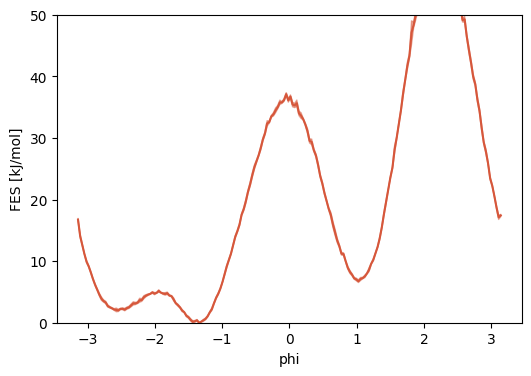

In [28]:
from mlcolvar.utils.fes import compute_fes
import mlcolvar.utils.plot

s = colvar['phi'].values

# compute weights
kbT = 2.5
w = np.exp(colvar['metad.bias'].values/kbT)

fig,ax = plt.subplots(figsize=(6,4),dpi=100)
fes,grid,bounds,error = compute_fes(s, weights=w, kbt=kbT, 
                                    blocks=5, bandwidth=0.01, 
                                    plot=True, ax = ax)
ax.set_xlabel('phi')
ax.set_ylabel('FES [kJ/mol]')
ax.set_ylim(0,50)

In [29]:
def augment_periodic(cv,weights=None,bandwidth=0.1):
    """Add points across the periodic boundaries (-np.pi and np.pi)

    Parameters
    ----------
    cv : np.array
    weigths : np.array, optional
    bandwidth : float, optional
    """
    mask = (cv < -np.pi + 3*bandwidth)
    index = np.argwhere(mask)[:,0]
    cv = np.insert( cv, index, cv[mask] + 2*np.pi )
    if weights is not None:
        weights = np.insert( weights, index, weights[mask] )

    mask = (cv > np.pi  - 5*bandwidth) & ( cv < np.pi )
    index = np.argwhere(mask)[:,0]
    cv = np.insert( cv, np.argwhere(mask)[:,0], cv[mask] - 2*np.pi )
    if weights is not None:
        weights = np.insert( weights, index, weights[mask] )

    return cv, weights

phi = colvar['phi'].values
psi = colvar['psi'].values
w = np.exp(colvar['metad.bias'].values/kbT)

bandwidth = 0.05

phi, w_phi = augment_periodic(phi,w,bandwidth)
psi, w_psi = augment_periodic(psi,w,bandwidth)

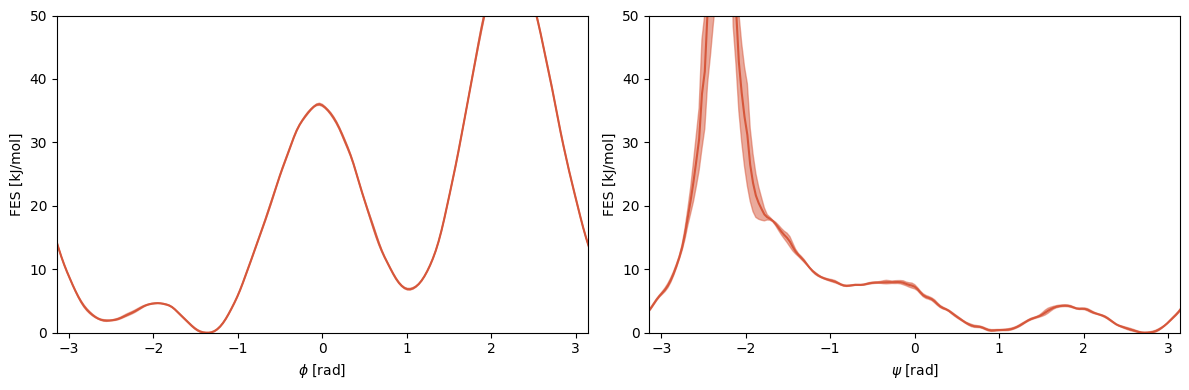

In [30]:
# compute weights
kbT = 2.5

#w = np.exp(colvar['metad.bias'].values/kbT)

#phi = colvar['phi'].values

fig,axs = plt.subplots(1,2,figsize=(12,4),dpi=100)
ax = axs[0]
fes,grid,bounds,error = compute_fes(phi, weights=w_phi, kbt=kbT, 
                                    blocks=5, bandwidth=bandwidth, 
                                    plot=True, ax = ax)
ax.set_xlabel(r'$\phi$ [rad]')
ax.set_ylabel('FES [kJ/mol]')
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(0,50)

ax = axs[1]
fes,grid,bounds,error = compute_fes(psi, weights=w_psi, kbt=kbT, 
                                    blocks=5, bandwidth=bandwidth, 
                                    plot=True, ax = ax)
ax.set_xlabel(r'$\psi$ [rad]')
ax.set_ylabel('FES [kJ/mol]')
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(0,50)

plt.tight_layout()

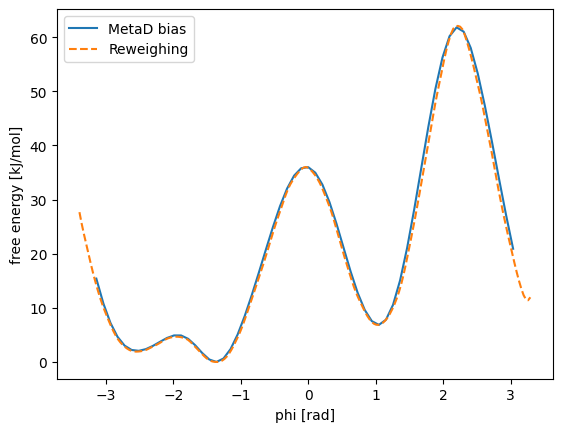

In [31]:
# now compare free energy from metadynamics bias and reweighting
data_b=load_dataframe(f"{folder_phi}/fes_100.dat")
data_r=load_dataframe(f"{folder_rw}/ffphi.dat")  

fes,grid,bounds,error = compute_fes(phi, weights=w_phi, kbt=kbT, 
                                    blocks=5, bandwidth=bandwidth, 
                                    plot=True, ax = ax)

# plot free energies
plt.plot(data_b["phi"],data_b["file.free"],label="MetaD bias")
plt.plot(grid,fes-min(fes),label="Reweighing", linestyle='--')
# x-y axis labels
plt.xlabel("phi [rad]")
plt.ylabel("free energy [kJ/mol]")
plt.legend()

### block analysis

In [32]:
print(folder_phi, folder_rw)

/home/dani/wslcoding/MCFM/ML-CV/data/2_biased-phi /home/dani/wslcoding/MCFM/ML-CV/data/2_biased-phi-rw


In [33]:
# CREATE FOLDER AND COPY INPUTS
folder_bl = DATA_DIR / "2_biased-phi-block/"
Path(folder_bl).mkdir(parents=True, exist_ok=True)

In [34]:
script_block_fes = str(BASE_DIR  / "notebook/do_block_fes.py")

In [35]:
os.environ["DIR_3"] = str(folder_rw)
os.environ["SCRIPT_FES"] = str(script_block_fes)

bash_script = """
# create phi.weight file with phi and weight from COLVAR_REWEIGHT
# find maximum of bias
bmax=`sort -n -k 4 "$DIR_3/COLVAR_REWEIGHT" | tail -n 1 | awk '{print $4}'`
# create phi.weight file
awk '{if($1!="#!") print $2,exp(($4-bm)/2.494339)}' bm=$bmax "$DIR_3/COLVAR_REWEIGHT" > phi.weight

# and now do block analysis with block sizes from 1 to 1000 (every 10)
# create PLUMED-like header for output file
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 # run the python script
 python3 "$SCRIPT_FES" phi.weight 1 -3.141593 3.141593 50 2.494339 $i
 # calculate average error along the free-energy profile
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks
"""

In [36]:
#execute(bash_script, folder=folder_bl)

Text(0, 0.5, 'Average error on free-energy profile [kJ/mol]')

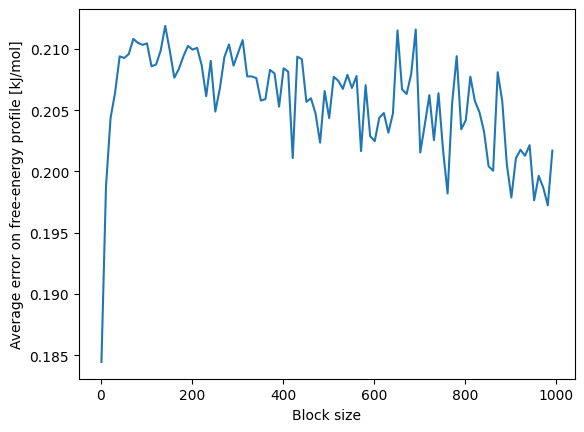

In [37]:
# import err.blocks file into pandas dataset
# data=plumed.read_as_pandas(str(f"{folder_bl}/err.blocks"))
data=load_dataframe(f"{folder_bl}/err.blocks")
# plot error as a function of block size
plt.plot(data["bsize"],data["err"])
# x-y axis labels
plt.xlabel("Block size")
plt.ylabel("Average error on free-energy profile [kJ/mol]")

### bad cv

bias $\psi$

In [38]:
# CREATE FOLDER AND COPY INPUTS
folder_bad = DATA_DIR / "3_biased-psi/"
Path(folder_bad).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_bad)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_bad)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [39]:
# WRITE PLUMED INPUT FILE
with open(folder_bad / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
#theta: TORSION ATOMS=6,5,7,9
#xi: TORSION ATOMS=16,15,17,19
#ene: ENERGY

# Compute descriptors
#INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Activate well-tempered metadynamics in psi
metad: METAD ARG=psi ...
   # Deposit a Gaussian every 500 time steps, with initial height 
   # equal to 1.2 kJ/mol and bias factor equal to 8 
   PACE=500 HEIGHT=1.2 BIASFACTOR=8 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE=HILLS GRID_MIN=-pi GRID_MAX=pi
...

# Print 
PRINT FMT=%g STRIDE={STRIDE} FILE=COLVAR ARG=phi,psi
ENDPLUMED
""")

In [40]:
#clean(folder_bad) # note: this deletes all previous results in folder!

In [41]:
# RUN GROMACS

#execute(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {test_num_steps} > alanine.out", folder=folder_bad)

In [42]:
# print command to run in terminal (for longer run)

print(f"cd {folder_bad}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} -v")

cd /home/dani/wslcoding/MCFM/ML-CV/data/3_biased-psi
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 10000000 -v


Text(0, 0.5, 'phi [rad]')

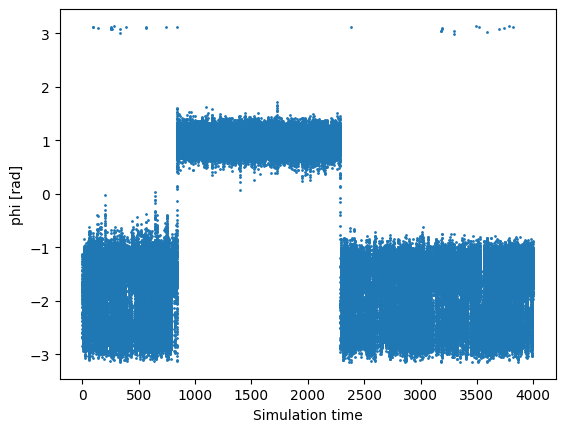

In [43]:
# visualize CV file
#data=plumed.read_as_pandas(str(folder_bad /"COLVAR"))
data=load_dataframe(f"{folder_bad}/COLVAR")
# plot phi during simulation (first 200k points)
plt.plot(data["time"][:200000],data["phi"][:200000],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("phi [rad]")

Text(0, 0.5, 'phi [rad]')

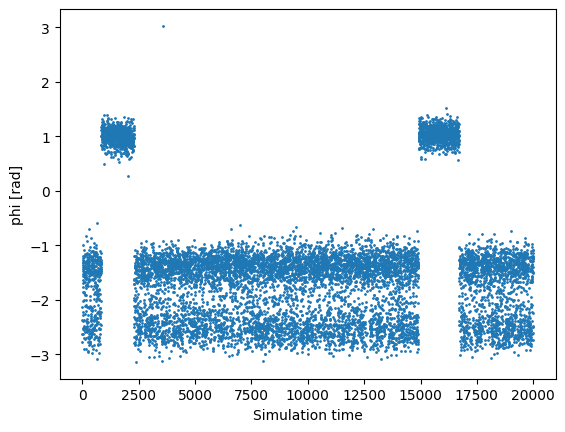

In [44]:
plt.plot(data["time"][::100],data["phi"][::100],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("phi [rad]")

Text(0, 0.5, 'height [kj/mol]')

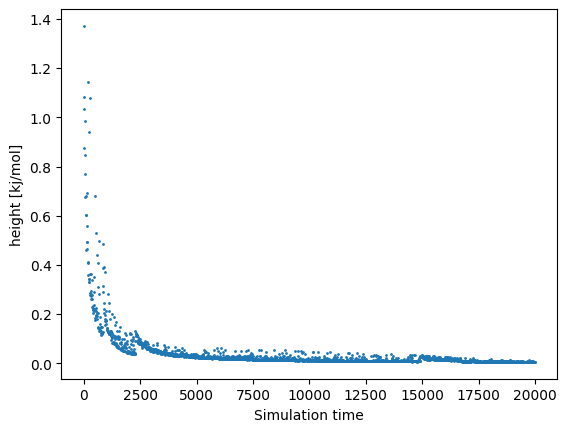

In [45]:
# visualize CV file
#data=plumed.read_as_pandas(str(folder_bad /"HILLS"))
data=load_dataframe(f"{folder_bad}/HILLS")
# plot phi during simulation (first 200k points)
plt.plot(data["time"][::10],data["height"][::10],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("height [kj/mol]")

In [46]:
#data_bad=plumed.read_as_pandas(str(folder_bad /"COLVAR"))
data_bad=load_dataframe(f"{folder_bad}/COLVAR")

data_bad.head()

,time,phi,psi,walker
0,0.00,-2.36867,2.64432,0
1,0.02,-2.38391,2.56521,0
2,0.04,-2.22548,2.51866,0
3,0.06,-2.29910,2.43971,0
4,0.08,-2.21197,2.34191,0


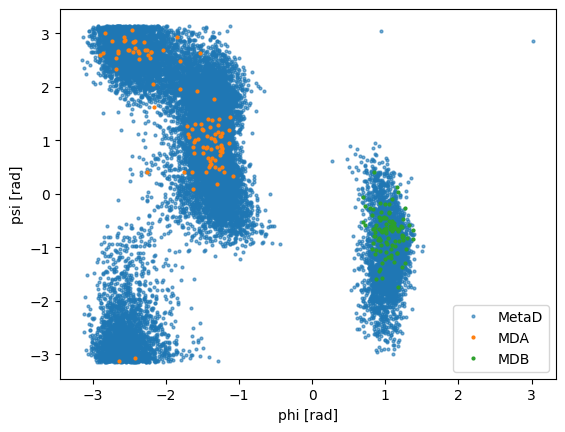

In [47]:
folderA = DATA_DIR / "0_unbiased-sA/"
folderB = DATA_DIR / "0_unbiased-sB/"

dataA = load_dataframe(f"{folderA}/COLVAR")
dataB = load_dataframe(f"{folderB}/COLVAR")
data_bad=load_dataframe(f"{folder_bad}/COLVAR")

# plot phi vs psi
plt.plot(data_bad["phi"][::50],data_bad["psi"][::50],'o', alpha=0.6, ms=2, label="MetaD")
plt.plot(dataA["phi"][::50],dataA["psi"][::50],'o', ms=2, label="MDA")
plt.plot(dataB["phi"][::50],dataB["psi"][::50],'o', ms=2, label="MDB")
# x-y axis labels
plt.xlabel("phi [rad]")
plt.ylabel("psi [rad]")
plt.legend()

In [48]:
# compute free energy as a function of simulation time

#plumed sum_hills --hills HILLS --stride 200 --mintozero
#execute("plumed sum_hills --hills HILLS --stride 200 --mintozero", folder=folder_bad)

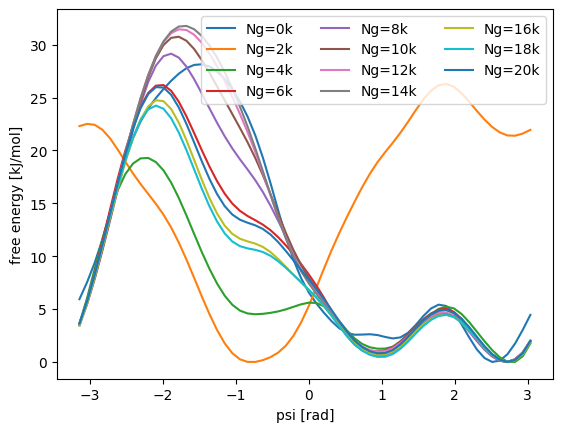

In [49]:
# plot free energy as a function of simulation time
#for i in range(0,51,10):
for i in range(0,101,10):    
 # import fes file into pandas dataset
 data = load_dataframe(f"{folder_bad}/fes_{i}.dat")
 # plot fes
 plt.plot(data["psi"],data["file.free"], label="Ng="+str(int(2*i/10))+"k") 
# labels
plt.xlabel("psi [rad]")
plt.ylabel("free energy [kJ/mol]")
plt.legend(ncol=3)

Text(0, 0.5, 'DeltaF [kJ/mol]')

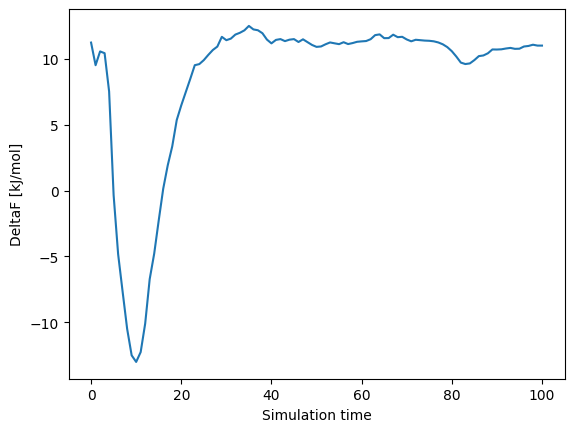

In [50]:
# calculate free-energy difference
DeltaF=[]; kbt=2.494339
# cycle on free-energy profiles
#for i in range(0,51):
for i in range(0,101):   
 # import fes file into pandas dataset
 data = load_dataframe(f"{folder_bad}/fes_{i}.dat")
 # find minimum value of fes
 minf = min(data["file.free"])
 # plot fes
 F0=0.0; F1=0.0
 for j in range(0, len(data["psi"])):
     psi = data["psi"][j]
     # calculate probability
     p = math.exp((-data["file.free"][j]+minf)/kbt)
     # integrate in the two basins
     if(-3<=psi<=-1):   F0 += p
     if(0.5<=psi<=1.5): F1 += p
 # calculate free energy difference and add to list
 DeltaF.append(-kbt*math.log(F0/F1))         
# plot
plt.plot(DeltaF) 
# labels
plt.xlabel("Simulation time")
plt.ylabel("DeltaF [kJ/mol]")

### reweighting bad cv

In [51]:
# CREATE FOLDER AND COPY INPUTS
folder_bad_rw = DATA_DIR / "3_biased-psi-rw/"
Path(folder_bad_rw).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_bad_rw)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_bad_rw)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [52]:
# WRITE PLUMED INPUT FILE
with open(folder_bad_rw / "plumed_reweight.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
#theta: TORSION ATOMS=6,5,7,9
#xi: TORSION ATOMS=16,15,17,19
#ene: ENERGY

# Compute descriptors
#INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Activate well-tempered metadynamics in psi
metad: METAD ARG=psi ...
   # Deposit a Gaussian every 10000000 time steps (never!), with initial height equal to 0.0 kJ/mol 
   PACE=10000000 HEIGHT=0.0 BIASFACTOR=8# <- this is the new stuff! 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE={folder_bad}/HILLS GRID_MIN=-pi GRID_MAX=pi
   # Say that METAD should be restarting (= reading an existing HILLS file) 
   RESTART=YES # <- this is the new stuff! 
...

# Use the metadynamics bias as argument
as: REWEIGHT_BIAS ARG=metad.bias 
# Calculate histograms of phi and psi dihedrals every 50 steps
# using the weights obtained from the metadynamics bias potentials (umbrella-sampling-like reweighting)
# Look at the manual to understand the parameters of the HISTOGRAM action!
hhphi: HISTOGRAM ARG=phi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as 
hhpsi: HISTOGRAM ARG=psi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as 
# Convert histograms h(s) to free energies F(s) = -kBT * log(h(s))
ffphi: CONVERT_TO_FES GRID=hhphi 
ffpsi: CONVERT_TO_FES GRID=hhpsi 
# Print out the free energies F(s) to file once the entire trajectory is processed
DUMPGRID GRID=ffphi FILE=ffphi.dat 
DUMPGRID GRID=ffpsi FILE=ffpsi.dat 

# Print out the values of phi, psi and the metadynamics bias potential
# Make sure you print out the 3 variables in the specified order at every step
PRINT ARG=phi,psi,metad.bias FILE=COLVAR_REWEIGHT STRIDE=1 # <- also change this one!
ENDPLUMED
""")

In [53]:
# analyze with PLUMED driver
#execute(f"plumed driver --mf_xtc {folder_bad}/alanine.xtc --plumed plumed_reweight.dat --kt 2.494339", folder=folder_bad_rw)

In [54]:
# now compare free energy from metadynamics bias and reweighting
data_bad=load_dataframe(f"{folder_bad}/fes_100.dat")
data_bad_rw=load_dataframe(f"{folder_bad_rw}/ffpsi.dat")               

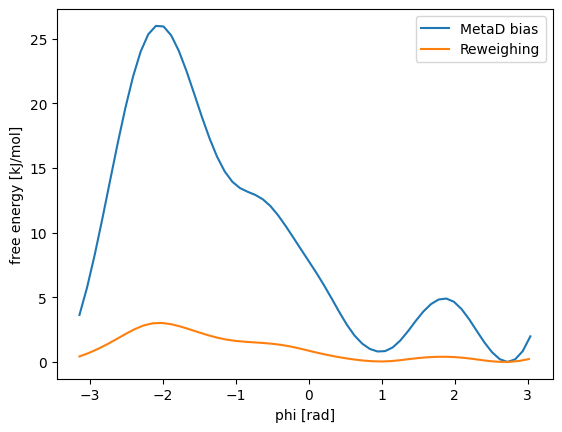

In [55]:


# plot free energies
plt.plot(data_bad["psi"],data_bad["file.free"],label="MetaD bias")
plt.plot(data_bad_rw["psi"],data_bad_rw["ffpsi"]-min(data_bad_rw["ffpsi"]),label="Reweighing")
# x-y axis labels
plt.xlabel("phi [rad]")
plt.ylabel("free energy [kJ/mol]")
plt.legend()

In [56]:
colvar_bad_rw=load_dataframe(f"{folder_bad_rw}/COLVAR_REWEIGHT") 

(0.0, 50.0)

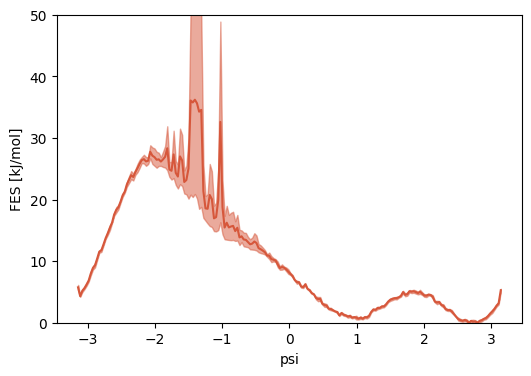

In [57]:
s = colvar_bad_rw['psi'].values

# compute weights
kbT = 2.5
w = np.exp(colvar_bad_rw['metad.bias'].values/kbT)

fig,ax = plt.subplots(figsize=(6,4),dpi=100)
fes,grid,bounds,error = compute_fes(s, weights=w, kbt=kbT, 
                                    blocks=5, bandwidth=0.01, 
                                    plot=True, ax = ax)
ax.set_xlabel('psi')
ax.set_ylabel('FES [kJ/mol]')
ax.set_ylim(0,50)

In [58]:
phi = colvar_bad_rw['phi'].values
psi = colvar_bad_rw['psi'].values
w = np.exp(colvar_bad_rw['metad.bias'].values/kbT)

bandwidth = 0.05

phi, w_phi = augment_periodic(phi,w,bandwidth)
psi, w_psi = augment_periodic(psi,w,bandwidth)

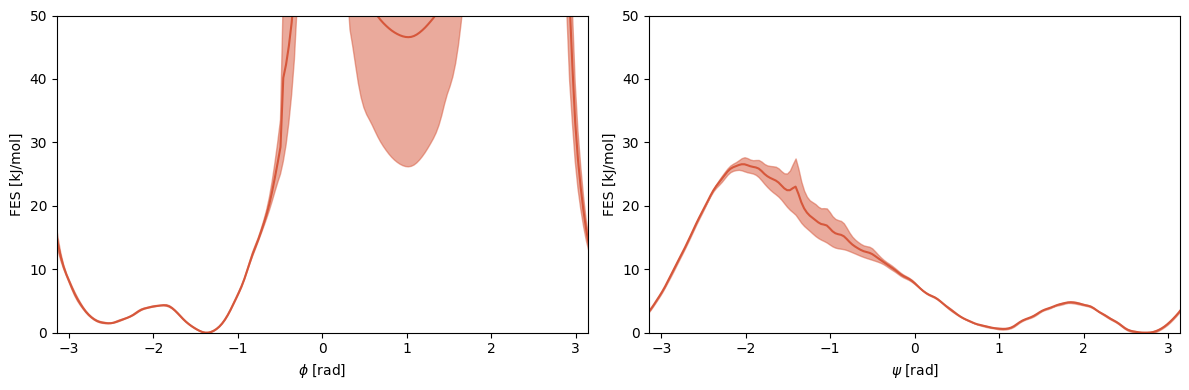

In [59]:
# compute weights
kbT = 2.5

#w = np.exp(colvar['metad.bias'].values/kbT)

#phi = colvar['phi'].values

fig,axs = plt.subplots(1,2,figsize=(12,4),dpi=100)
ax = axs[0]
fes,grid,bounds,error = compute_fes(phi, weights=w_phi, kbt=kbT, 
                                    blocks=5, bandwidth=bandwidth, 
                                    plot=True, ax = ax)
ax.set_xlabel(r'$\phi$ [rad]')
ax.set_ylabel('FES [kJ/mol]')
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(0,50)

ax = axs[1]
fes,grid,bounds,error = compute_fes(psi, weights=w_psi, kbt=kbT, 
                                    blocks=5, bandwidth=bandwidth, 
                                    plot=True, ax = ax)
ax.set_xlabel(r'$\psi$ [rad]')
ax.set_ylabel('FES [kJ/mol]')
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(0,50)

plt.tight_layout()

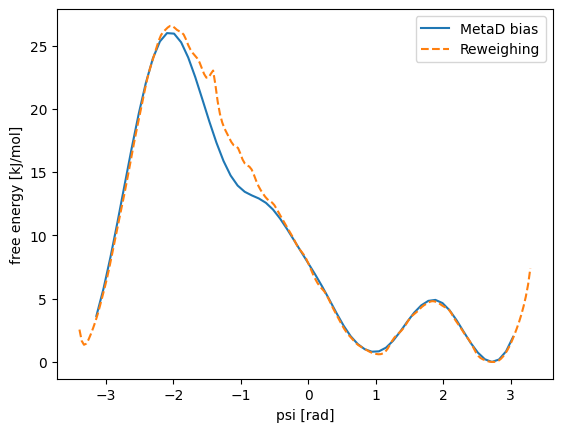

In [60]:
# now compare free energy from metadynamics bias and reweighting
data_b=load_dataframe(f"{folder_bad}/fes_100.dat")
data_r=load_dataframe(f"{folder_bad_rw}/ffpsi.dat")  

fes,grid,bounds,error = compute_fes(psi, weights=w_psi, kbt=kbT, 
                                    blocks=5, bandwidth=bandwidth, 
                                    plot=True, ax = ax)

# plot free energies
plt.plot(data_b["psi"],data_b["file.free"],label="MetaD bias")
plt.plot(grid,fes-min(fes),label="Reweighing", linestyle='--')
# x-y axis labels
plt.xlabel("psi [rad]")
plt.ylabel("free energy [kJ/mol]")
plt.legend()

### block analysis bad cv

In [61]:
# CREATE FOLDER AND COPY INPUTS
folder_bad_bl = DATA_DIR / "3_biased-psi-block/"
Path(folder_bad_bl).mkdir(parents=True, exist_ok=True)

In [62]:
os.environ["DIR_3"] = str(folder_bad_rw)
os.environ["SCRIPT_FES"] = str(script_block_fes)

bash_script = """
# create phi.weight file with phi and weight from COLVAR_REWEIGHT
# find maximum of bias
bmax=`sort -n -k 4 "$DIR_3/COLVAR_REWEIGHT" | tail -n 1 | awk '{print $4}'`
# create phi.weight file
awk '{if($1!="#!") print $2,exp(($4-bm)/2.494339)}' bm=$bmax "$DIR_3/COLVAR_REWEIGHT" > phi.weight

# and now do block analysis with block sizes from 1 to 1000 (every 10)
# create PLUMED-like header for output file
echo "#! FIELDS bsize err" > err.blocks
for i in `seq 1 10 1000`
do
 # run the python script
 python3 "$SCRIPT_FES" phi.weight 1 -3.141593 3.141593 50 2.494339 $i
 # calculate average error along the free-energy profile
 awk 'BEGIN{tot=0}{tot+=$3}END{print i,tot/NR}' i=$i fes.$i.dat
done >> err.blocks
"""

In [63]:
#execute(bash_script, folder=folder_bad_bl)

Text(0, 0.5, 'Average error on free-energy profile [kJ/mol]')

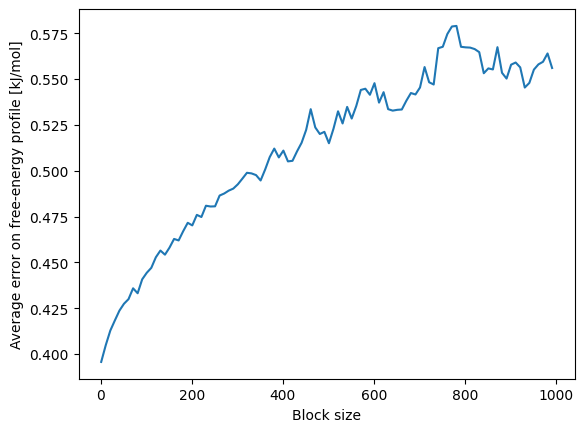

In [64]:
# import err.blocks file into pandas dataset
data=load_dataframe(f"{folder_bad_bl}/err.blocks")
# plot error as a function of block size
plt.plot(data["bsize"],data["err"])
# x-y axis labels
plt.xlabel("Block size")
plt.ylabel("Average error on free-energy profile [kJ/mol]")

### biased simulation using deepLDA CV

In [73]:
# CREATE FOLDER AND COPY INPUTS
folder_1 = DATA_DIR / "1_meta-deeplda/"
folder_mlcv = DATA_DIR / "3_biased-mlcv/"
Path(folder_mlcv).mkdir(parents=True, exist_ok=True)

#execute(f"cp {folder_1}/COLVAR .", folder_mlcv)
#execute(f"cp {folder_1}/HILLS .", folder_mlcv)

execute(f"cp {folder_1}/model.ptc .", folder_mlcv)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_mlcv)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_mlcv)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/data/1_meta-deeplda/model.ptc .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .


In [74]:
# WRITE PLUMED INPUT FILE
with open(folder_mlcv / "plumed.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
theta: TORSION ATOMS=6,5,7,9
xi: TORSION ATOMS=16,15,17,19
ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Compute DeepLDA CV
deep: PYTORCH_MODEL FILE=model.ptc    ARG=d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,d_11_15,d_11_16,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19

metad: METAD ARG=deep.node-0 ...
   # Deposit a Gaussian every 500 time steps, with initial height 
   # equal to 1.2 kJ/mol and bias factor equal to 8 
   PACE=500 HEIGHT=1.2 BIASFACTOR=8 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE=HILLS GRID_MIN=-pi GRID_MAX=pi 
...

# Print 
PRINT FMT=%g STRIDE={STRIDE} FILE=COLVAR ARG=*
ENDPLUMED
""")

In [72]:
# print command to run in terminal (for longer run)

print(f"cd {folder_mlcv}")
print(f"{GMX_CMD} mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps {num_steps} -v")

cd /home/dani/wslcoding/MCFM/ML-CV/data/3_biased-mlcv
gmx_mpi mdrun -s input.tpr -deffnm alanine -plumed plumed.dat -ntomp 1 -nsteps 10000000 -v


Text(0, 0.5, 'phi [rad]')

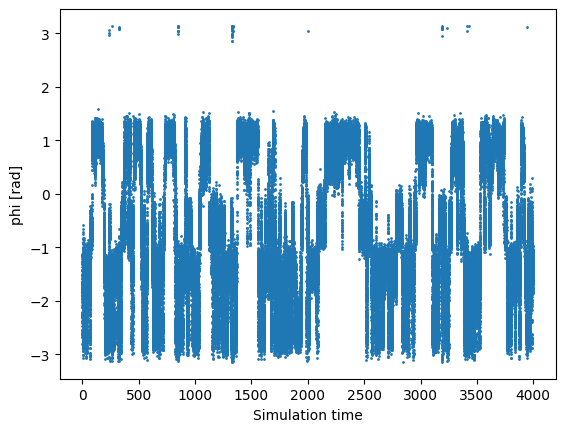

In [75]:
# visualize CV file
#data=plumed.read_as_pandas(str(folder_phi /"COLVAR"))
# use load_dataframe because plumed module give me errors
data=load_dataframe(f"{folder_mlcv}/COLVAR")
# plot phi during simulation (first 200k points)
plt.plot(data["time"][:200000],data["phi"][:200000],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("phi [rad]")

Text(0, 0.5, 'phi [rad]')

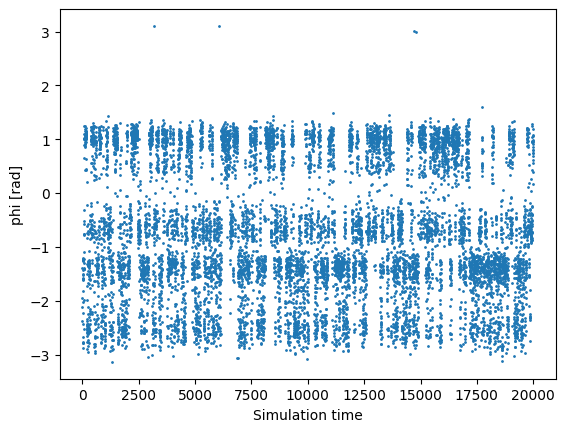

In [76]:
plt.plot(data["time"][::100],data["phi"][::100],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("phi [rad]")

Text(0, 0.5, 'height [kj/mol]')

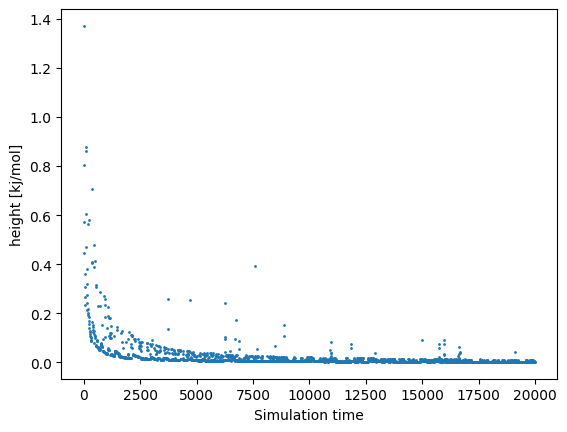

In [77]:
# visualize CV file
#data=plumed.read_as_pandas(str(folder_phi /"HILLS"))
data=load_dataframe(f"{folder_mlcv}/HILLS")
# plot phi during simulation (first 200k points)
plt.plot(data["time"][::10],data["height"][::10],'o', ms=1)
# x-y axis labels
plt.xlabel("Simulation time")
plt.ylabel("height [kj/mol]")

In [85]:
data_ml=load_dataframe(f"{folder_mlcv}/COLVAR")
data_ml.head()

,time,phi,psi,theta,xi,ene,d_2_5,d_2_6,d_2_7,d_2_9,...,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19,deep.node-0,metad.bias,walker
0,0.00,-2.36867,2.64432,-0.202258,0.048056,-41.4583,0.152064,0.233505,0.241173,0.379827,...,0.452694,0.126976,0.130073,0.244001,0.227324,0.281913,0.148169,-1.13657,0.0,0
1,0.02,-2.38391,2.56521,-0.098195,0.098889,0.0000,0.150791,0.239520,0.239972,0.379414,...,0.449806,0.127696,0.130752,0.238106,0.227686,0.276062,0.142131,-1.15485,0.0,0
2,0.04,-2.22548,2.51866,-0.229770,0.062602,0.0000,0.150503,0.239476,0.243254,0.382465,...,0.465213,0.122604,0.130031,0.250935,0.219767,0.287098,0.147038,-1.14435,0.0,0
3,0.06,-2.29910,2.43971,0.055923,-0.082184,0.0000,0.151211,0.235485,0.243182,0.379133,...,0.475438,0.127531,0.138214,0.250182,0.238033,0.296741,0.145515,-1.12107,0.0,0
4,0.08,-2.21197,2.34191,-0.045202,-0.079904,0.0000,0.151422,0.236207,0.239241,0.375772,...,0.477123,0.123217,0.133302,0.249054,0.217254,0.277097,0.142154,-1.14470,0.0,0


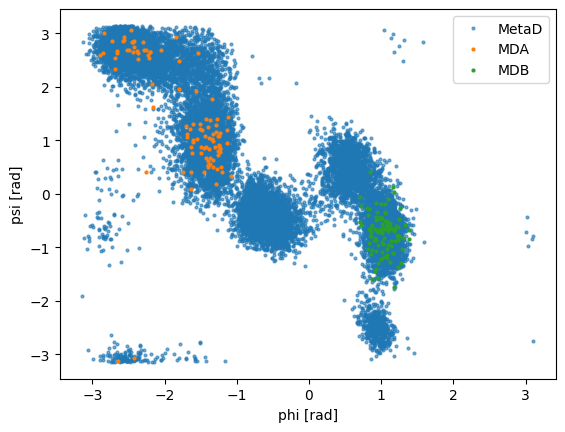

In [86]:
folderA = DATA_DIR / "0_unbiased-sA/"
folderB = DATA_DIR / "0_unbiased-sB/"

# dataA = plumed.read_as_pandas(str(folderA / "COLVAR"))
# dataB = plumed.read_as_pandas(str(folderB / "COLVAR"))
# data_phi=plumed.read_as_pandas(str(folder_phi /"COLVAR"))

dataA=load_dataframe(f"{folderA}/COLVAR")
dataB=load_dataframe(f"{folderB}/COLVAR")

# plot phi vs psi
plt.plot(data_ml["phi"][::50],data_ml["psi"][::50],'o', alpha=0.6, ms=2, label="MetaD")
plt.plot(dataA["phi"][::50],dataA["psi"][::50],'o', ms=2, label="MDA")
plt.plot(dataB["phi"][::50],dataB["psi"][::50],'o', ms=2, label="MDB")
# x-y axis labels
plt.xlabel("phi [rad]")
plt.ylabel("psi [rad]")
plt.legend()

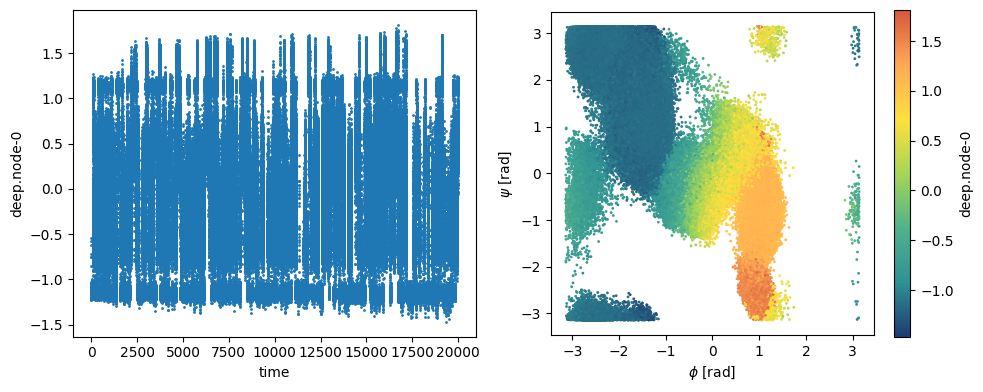

In [87]:
fig,axs = plt.subplots(1,2,figsize=(10,4),dpi=100)
# Time evolution (DeepLDA)
data_ml.plot.scatter('time','deep.node-0',s=1,ax=axs[0])
axs[1].set_xlabel('Time [ps]')
axs[1].set_xlabel('DeepLDA')
# 2D scatter plot colored with DeepLDA
data_ml.plot.scatter('phi','psi',c='deep.node-0',s=1,cmap='fessa',ax=axs[1])
axs[1].set_xlabel(r'$\phi$ [rad]')
axs[1].set_ylabel(r'$\psi$ [rad]')
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()

In [ ]:
# compute free energy as a function of simulation time

#plumed sum_hills --hills HILLS --stride 200 --mintozero
#execute("plumed sum_hills --hills HILLS --stride 200 --mintozero", folder=folder_mlcv)

Completed: plumed sum_hills --hills HILLS --stride 200 --mintozero


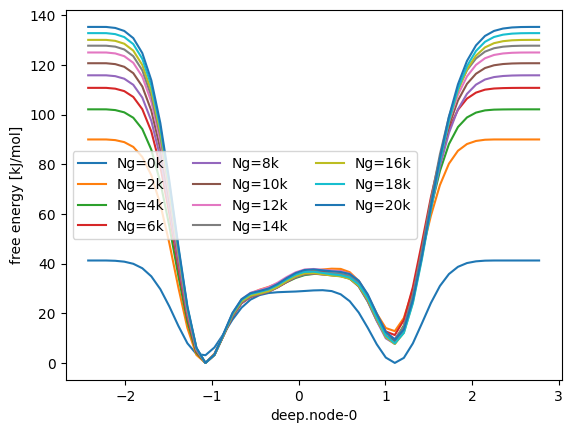

In [91]:
# plot free energy as a function of simulation time
#for i in range(0,51,10):
for i in range(0,101,10):    
 # import fes file into pandas dataset
#  data=plumed.read_as_pandas(str(folder_phi /"fes_")+str(i)+".dat")
 data = load_dataframe(f"{folder_mlcv}/fes_{i}.dat")

 # plot fes
 plt.plot(data["deep.node-0"],data["file.free"], label="Ng="+str(int(2*i/10))+"k") 
# labels
plt.xlabel("deep.node-0")
plt.ylabel("free energy [kJ/mol]")
plt.legend(ncol=3)

Text(0, 0.5, 'DeltaF [kJ/mol]')

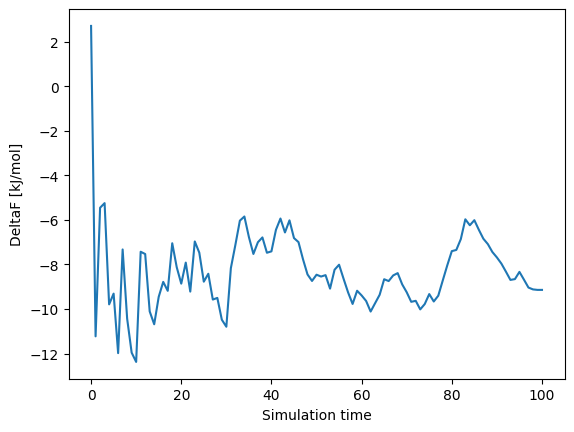

In [93]:
# calculate free-energy difference
DeltaF=[]; kbt=2.494339
# cycle on free-energy profiles
#for i in range(0,51):
for i in range(0,101):   
 # import fes file into pandas dataset
#  data=plumed.read_as_pandas(str(folder_phi /"fes_")+str(i)+".dat")
 data = load_dataframe(f"{folder_mlcv}/fes_{i}.dat")
 # find minimum value of fes
 minf = min(data["file.free"])
 # plot fes
 F0=0.0; F1=0.0
 for j in range(0, len(data["deep.node-0"])):
     dn = data["deep.node-0"][j]
     # calculate probability
     p = math.exp((-data["file.free"][j]+minf)/kbt)
     # integrate in the two basins
     if(-2<=dn<=-0.5):   F0 += p
     if(0.5<=dn<=1.5): F1 += p
 # calculate free energy difference and add to list
 DeltaF.append(-kbt*math.log(F0/F1))         
# plot
plt.plot(DeltaF) 
# labels
plt.xlabel("Simulation time")
plt.ylabel("DeltaF [kJ/mol]")

### reweighting deepLDA

In [95]:
# CREATE FOLDER AND COPY INPUTS
folder_ml_rw = DATA_DIR / "3_biased-mlcv-rw/"
Path(folder_ml_rw).mkdir(parents=True, exist_ok=True)

execute(f"cp {MD_IN_DIR}/input.ala2.pdb .", folder_ml_rw)
execute(f"cp {MD_IN_DIR}/input.tpr .", folder_ml_rw)
execute(f"cp {folder_1}/model.ptc .", folder_ml_rw)

Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.ala2.pdb .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/input/md_inputs/input.tpr .
Completed: cp /home/dani/wslcoding/MCFM/ML-CV/data/1_meta-deeplda/model.ptc .


In [ ]:
# WRITE PLUMED INPUT FILE
with open(folder_ml_rw / "plumed_reweight.dat", "w") as f:
    f.write(f"""\
# vim:ft=plumed

# Compute torsion angles, as well as energy
MOLINFO STRUCTURE=input.ala2.pdb
phi: TORSION ATOMS=@phi-2
psi: TORSION ATOMS=@psi-2
#theta: TORSION ATOMS=6,5,7,9
#xi: TORSION ATOMS=16,15,17,19
#ene: ENERGY

# Compute descriptors
INCLUDE FILE={INPUT_DIR}/plumed-distances.dat

# Compute DeepLDA CV
deep: PYTORCH_MODEL FILE=model.ptc    ARG=d_2_5,d_2_6,d_2_7,d_2_9,d_2_11,d_2_15,d_2_16,d_2_17,d_2_19,d_5_6,d_5_7,d_5_9,d_5_11,d_5_15,d_5_16,d_5_17,d_5_19,d_6_7,d_6_9,d_6_11,d_6_15,d_6_16,d_6_17,d_6_19,d_7_9,d_7_11,d_7_15,d_7_16,d_7_17,d_7_19,d_9_11,d_9_15,d_9_16,d_9_17,d_9_19,d_11_15,d_11_16,d_11_17,d_11_19,d_15_16,d_15_17,d_15_19,d_16_17,d_16_19,d_17_19

metad: METAD ARG=deep.node-0 ...
   # Deposit a Gaussian every 10000000 time steps (never!), with initial height equal to 0.0 kJ/mol 
   PACE=10000000 HEIGHT=0.0 BIASFACTOR=8# <- this is the new stuff! 
   # Gaussian width (sigma) should be chosen based on the CV fluctuations in unbiased run 
   SIGMA=0.3 
   # Gaussians will be written to file and also stored on grid 
   FILE={folder_mlcv}/HILLS GRID_MIN=-pi GRID_MAX=pi
   # Say that METAD should be restarting (= reading an existing HILLS file) 
   RESTART=YES # <- this is the new stuff! 
...

# Use the metadynamics bias as argument
as: REWEIGHT_BIAS ARG=metad.bias 
# Calculate histograms of phi and psi dihedrals every 50 steps
# using the weights obtained from the metadynamics bias potentials (umbrella-sampling-like reweighting)
# Look at the manual to understand the parameters of the HISTOGRAM action!
hhphi: HISTOGRAM ARG=phi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as 
hhpsi: HISTOGRAM ARG=psi STRIDE=1 GRID_MIN=-pi GRID_MAX=pi GRID_BIN=50 BANDWIDTH=0.25 LOGWEIGHTS=as 
# Convert histograms h(s) to free energies F(s) = -kBT * log(h(s))
ffphi: CONVERT_TO_FES GRID=hhphi 
ffpsi: CONVERT_TO_FES GRID=hhpsi 
# Print out the free energies F(s) to file once the entire trajectory is processed
DUMPGRID GRID=ffphi FILE=ffphi.dat 
DUMPGRID GRID=ffpsi FILE=ffpsi.dat 

# Print out the values of phi, psi and the metadynamics bias potential
# Make sure you print out the 3 variables in the specified order at every step
PRINT ARG=phi,psi,metad.bias FILE=COLVAR_REWEIGHT STRIDE=1 # <- also change this one!
ENDPLUMED
""")